In [2]:
# Bibliotecas
import matplotlib.pyplot as plt
import pandas as pd
import polars as pl
import numpy as np
import glob
import math
from scipy.optimize import curve_fit
import seaborn as sns
%matplotlib inline
from sympy import *
from scipy.special import gamma, factorial
#init_printing( use_latex='mathjax' )

Text(0, 0.5, 'log s')

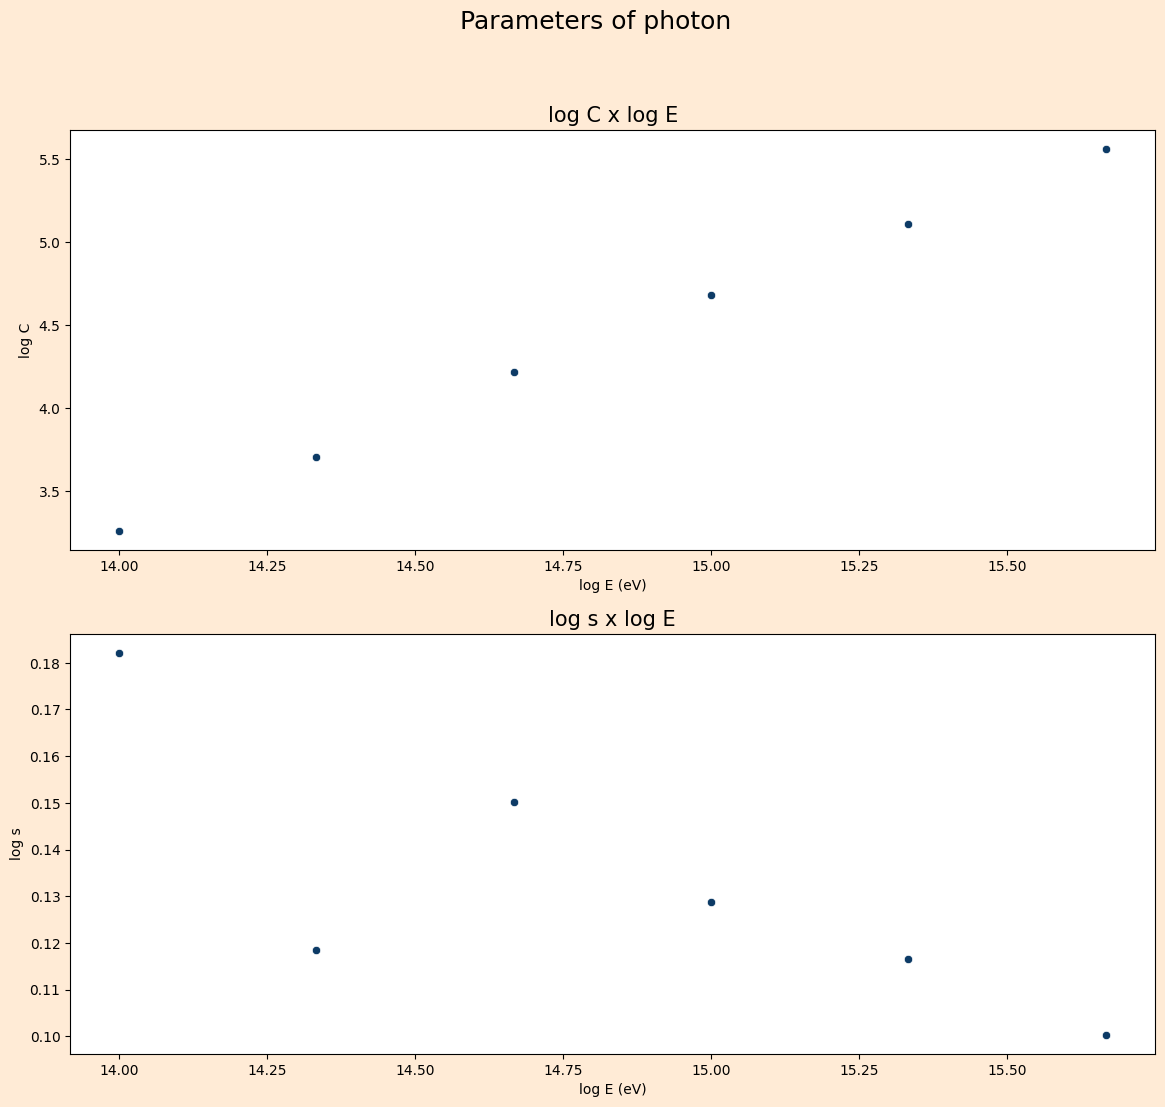

In [2]:
# Fóton

C = [1824,5066,1.644E04,4.824E04,1.295E05,3.665E05]
s = [1.521, 1.314,1.413, 1.345,1.308,1.26]
E = [1E14, 2.15E14, 4.64E14,1E15,2.15E15,4.64E15]


logC = np.log10(C)
logs = np.log10(s)
logE = np.log10(E)


fig, ax = plt.subplots(2, 1, figsize = (14, 12), facecolor = '#FFEBD6')
fig.suptitle('Parameters of photon', size = 18)
#fig.tight_layout(pad = 5)
sns.scatterplot(x = logE, y = logC, ax = ax[0], color = '#0D3B66')
sns.scatterplot(x = logE, y = logs, ax = ax[1], color = '#0D3B66')

ax[0].set_title('log C x log E', size = 15)
ax[0].set_xlabel('log E (eV)')
ax[0].set_ylabel('log C')
#ax[0,0].set_xscale('log')
#ax[0,0].set_yscale('log')

ax[1].set_title('log s x log E', size = 15)
ax[1].set_xlabel('log E (eV)')
ax[1].set_ylabel('log s')
#ax[0,1].set_xscale('log')
#ax[0,1].set_yscale('log')

#yticks - numeros na escala


/tmp/ipykernel_34598/867406108.py:23: RuntimeWarning: invalid value encountered in log10
  return np.log10(k*x**p)
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


[3.82347672e-17 1.69868070e-02]
[3.26643042 3.7282313  4.19231183 4.65556235 5.11736323 5.58144376]


logC,logE_S,logE_R,error (%)
f64,f64,f64,f64
3.261025,14.0,13.996109,0.027795
3.704665,14.332438,14.315474,0.118365
4.215902,14.666518,14.6835,0.115786
4.683407,15.0,15.020045,0.133632
5.11227,15.332438,15.328772,0.023914
5.564074,15.666518,15.654014,0.079814


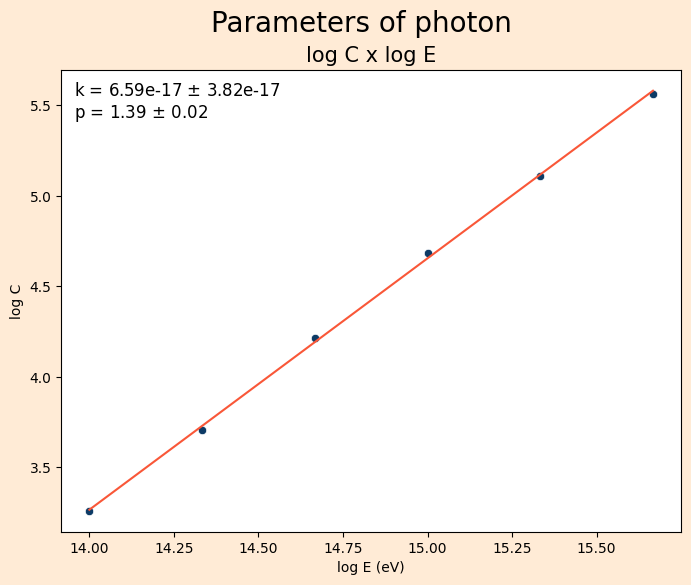

In [3]:
# Fit do fóton

C = [1824,5066,1.644E04,4.824E04,1.295E05,3.665E05]
E = [1E14, 2.15E14, 4.64E14,1E15,2.15E15,4.64E15]

logC = np.log10(C)
logE = np.log10(E)


fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
fig.suptitle('Parameters of photon', size = 20)
#fig.tight_layout()


ax.set_title('log C x log E', size = 15)
ax.set_xlabel('log E (eV)')
ax.set_ylabel('log C')
ax.set_facecolor('white')


#Fit
def power(x, k, p):
    return np.log10(k*x**p)

initial_guess = [1,1]

coefficients, cov = curve_fit(power, E, np.log10(C), p0=initial_guess)

inc = np.sqrt(np.diag(cov))
print(np.sqrt(np.diag(cov)))

print(power(E,*coefficients))

ax.plot(logE, power(E,*coefficients), color = '#F95738')
sns.scatterplot(x = logE, y = logC, color = '#0D3B66', ax = ax)

ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'
          .format(coefficients[0],inc[0],coefficients[1],inc[1]),
          title_fontsize = 12,facecolor = 'white', frameon = False)


logE_0_array = ((np.log10(C/coefficients[0]))/coefficients[1])

logE_0 = logE_0_array.tolist()

data = {
    'logC':logC,
    'logE_S':logE,
    'logE_R':logE_0
}

df = pl.DataFrame(data)

df = df.with_columns(
        abs((((pl.col('logE_R')-pl.col('logE_S'))/pl.col('logE_S'))*100)).alias('error (%)')
)
df

[0.05911377]
[0.14873298 0.14215286 0.1358335  0.12980563 0.12406287 0.1185477 ]
[0.18212921 0.11859537 0.15014216 0.12872228 0.11660774 0.10037055]


<AxesSubplot: title={'center': 'log s x log E'}, xlabel='log E (eV)', ylabel='log s'>

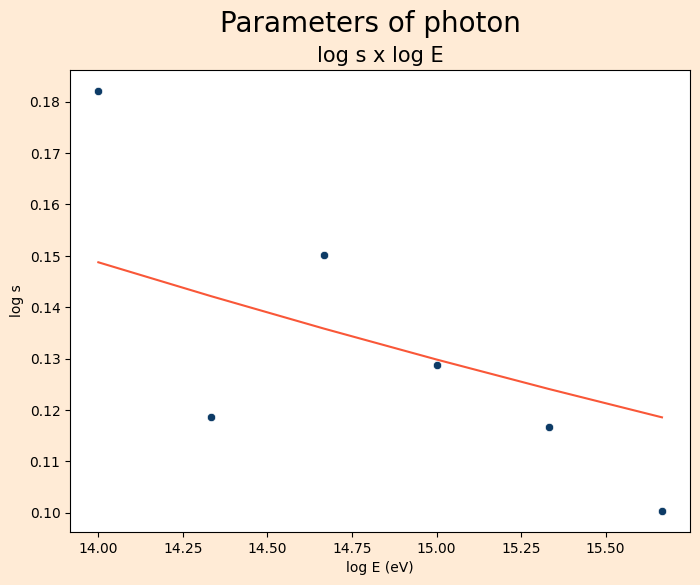

In [4]:
# Fit do fóton

C = [1824,5066,1.644E04,4.824E04,1.295E05,3.665E05]
s = [1.521, 1.314,1.413, 1.345,1.308,1.26]
E = [1E14, 2.15E14, 4.64E14,1E15,2.15E15,4.64E15]

logs = np.log10(s)
logE = np.log10(E)


fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
fig.suptitle('Parameters of photon', size = 20)
#fig.tight_layout()


ax.set_title('log s x log E', size = 15)
ax.set_xlabel('log E (eV)')
ax.set_ylabel('log s')
ax.set_facecolor('white')


#Fit
def power(x, p):
    return 1/np.power(x,p)

initial_guess = [0.1]

coefficients, cov = curve_fit(power, E, logs, p0=initial_guess)

inc = np.sqrt(np.diag(cov))
#print(np.sqrt(np.diag(cov)))
print(coefficients)

print(power(E,coefficients))
print(logs)

ax.plot(logE, power(E,coefficients), color = '#F95738')
sns.scatterplot(x = logE, y = logs, color = '#0D3B66', ax = ax)




/tmp/ipykernel_34598/2828231561.py:61: RuntimeWarning: invalid value encountered in log10
  return np.log10(k*x**p)
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


[3.74578735e-15 2.45148081e-02]


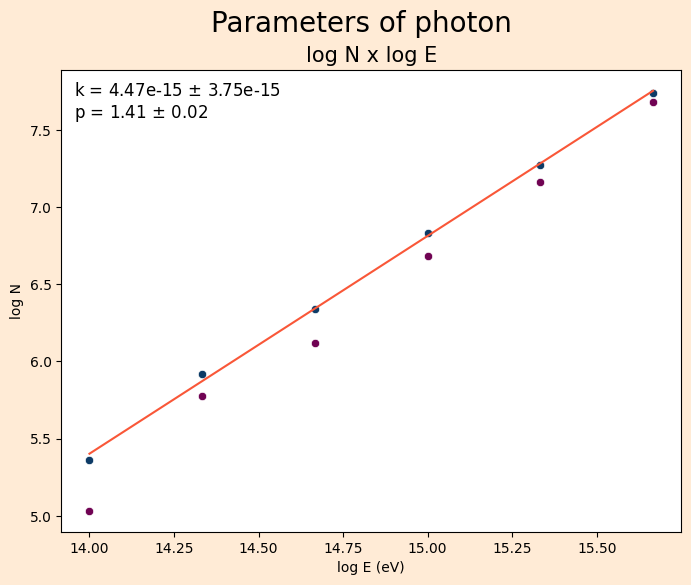

In [5]:
# Relação entre C e o número total de partículas (N)

# Fóton

# A partir da densidade

C = [1824,5066,1.644E04,4.824E04,1.295E05,3.665E05]
s = [1.521, 1.314,1.413, 1.345,1.308,1.26]
E = [1E14, 2.15E14, 4.64E14,1E15,2.15E15,4.64E15]
D = [0.0343062, 0.189931, 0.416183, 1.5341, 4.63826, 15.1964]
N_t = []
N_s = []


for i  in range(len(C)):
    aux = D[i]*math.pi*1000**2
    N_s.append(aux)  

output_path = '/home/orfei/mestrado/progs/lateral_distribution/eletrons/data/photon/*'

for file in glob.glob(output_path):
    tamanho = len(pl.scan_csv(file).collect(streaming=True))
    N_t.append(tamanho)

N_t.sort()
N_t.pop(0)

data = {
    'E':E,
    'C':C,
    'N_t':N_t
}

df = pl.DataFrame(data)

df = df.with_columns(
        (pl.col('C')/pl.col('N_t')).alias('alpha')
)
df

logN = np.log10(N_t)
logE = np.log10(E)
logN_s = np.log10(N_s)

fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
fig.suptitle('Parameters of photon', size = 20)
#fig.tight_layout()


ax.set_title('log N x log E', size = 15)
ax.set_xlabel('log E (eV)')
ax.set_ylabel('log N')
ax.set_facecolor('white')


sns.scatterplot(x = logE, y = logN, color = '#0D3B66', ax = ax)
sns.scatterplot(x = logE, y = logN_s, color = '#700353', ax = ax)

#Fit
def power(x, k, p):
    return np.log10(k*x**p)

initial_guess = [1,1]

coefficients, cov = curve_fit(power, E, np.log10(N_t), p0=initial_guess)

inc = np.sqrt(np.diag(cov))
print(np.sqrt(np.diag(cov)))

ax.plot(logE, power(E,*coefficients), color = '#F95738')

ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'
          .format(coefficients[0],inc[0],coefficients[1],inc[1]),
          title_fontsize = 12,facecolor = 'white', frameon = False)


/tmp/ipykernel_34598/3056220088.py:64: RuntimeWarning: invalid value encountered in log10
  return np.log10(k*x**p)
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


[3.74578735e-15 2.45148081e-02]


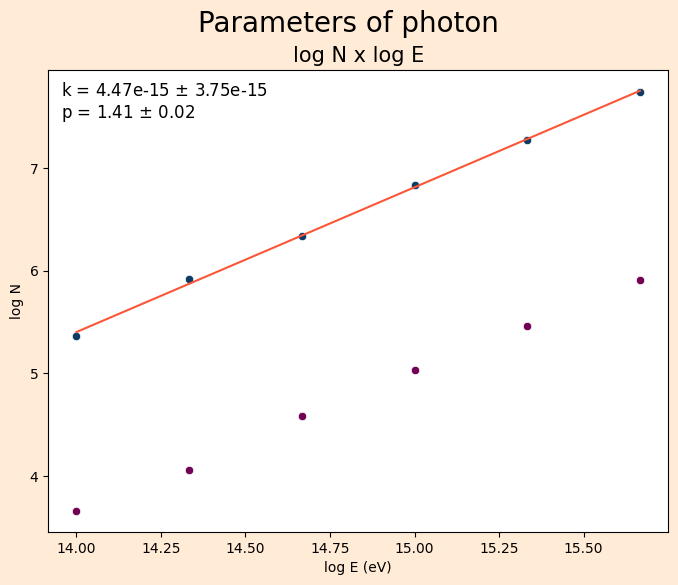

In [6]:
# Relação entre C e o número total de partículas (N)

# Fóton

# Calculando o número de elétrons a partir da idade s e do parâmetro C, onde N = C/K(s)

C = [1824,5066,1.644E04,4.824E04,1.295E05,3.665E05]
s = [1.521, 1.314,1.413, 1.345,1.308,1.26]
E = [1E14, 2.15E14, 4.64E14,1E15,2.15E15,4.64E15]
D = [0.0343062, 0.189931, 0.416183, 1.5341, 4.63826, 15.1964]
K = []
N_t = []
N_c = []


for i  in range(len(C)):
    aux = gamma(4.5 - s[i])/(2*math.pi*gamma(s[i])*gamma(4.5 - 2*s[i]))
    K.append(aux)
    aux2 = C[i]/K[i]
    N_c.append(aux2)  

output_path = '/home/orfei/mestrado/progs/lateral_distribution/eletrons/data/photon/*'

for file in glob.glob(output_path):
    tamanho = len(pl.scan_csv(file).collect(streaming=True))
    N_t.append(tamanho)

N_t.sort()
N_t.pop(0)

data = {
    'E':E,
    'C':C,
    'N_t':N_t
}

df = pl.DataFrame(data)

df = df.with_columns(
        (pl.col('C')/pl.col('N_t')).alias('alpha')
)
df

logN = np.log10(N_t)
logE = np.log10(E)
logN_c = np.log10(N_c)

fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
fig.suptitle('Parameters of photon', size = 20)
#fig.tight_layout()


ax.set_title('log N x log E', size = 15)
ax.set_xlabel('log E (eV)')
ax.set_ylabel('log N')
ax.set_facecolor('white')


sns.scatterplot(x = logE, y = logN, color = '#0D3B66', ax = ax)
sns.scatterplot(x = logE, y = logN_c, color = '#700353', ax = ax)

#Fit
def power(x, k, p):
    return np.log10(k*x**p)

initial_guess = [1,1]

coefficients, cov = curve_fit(power, E, np.log10(N_t), p0=initial_guess)

inc = np.sqrt(np.diag(cov))
print(np.sqrt(np.diag(cov)))

ax.plot(logE, power(E,*coefficients), color = '#F95738')

ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'
          .format(coefficients[0],inc[0],coefficients[1],inc[1]),
          title_fontsize = 12,facecolor = 'white', frameon = False)


/tmp/ipykernel_22890/2768682291.py:24: RuntimeWarning: invalid value encountered in log10
  return np.log10(k*x**p)
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


[3.41022156e-14 3.30684044e-02]
[3.44027963 3.84302113 4.24775072 4.65175646 5.05449795 5.45922755]


logC,logE_S,logE_R,error (%)
f64,f64,f64,f64
3.426999,14.0,13.989038,0.078303
3.806994,14.332438,14.3027,0.207491
4.276921,14.666518,14.690596,0.164172
4.721068,15.0,15.057213,0.381418
5.039017,15.332438,15.31966,0.083342
5.425534,15.666518,15.638706,0.177524


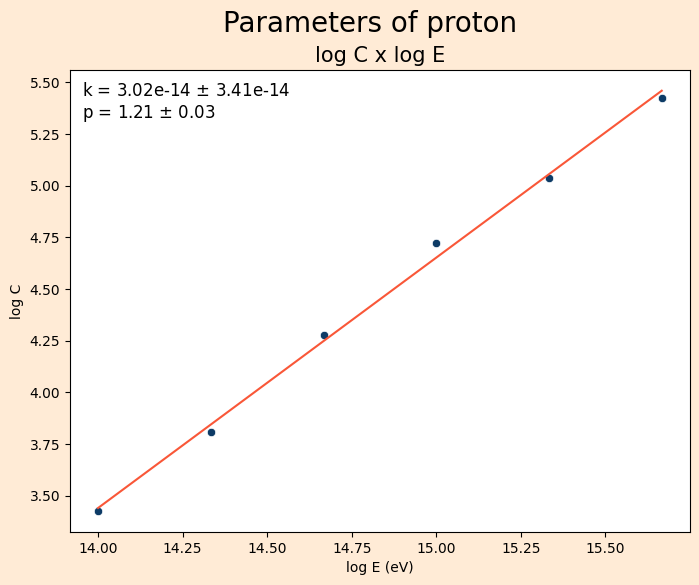

In [3]:
# Fit do próton

C = [2673,6412,1.892E04,5.261E04,1.094E05,2.664E05]
s = [1.495,1.379,1.465, 1.38,1.362,1.315]
E = [1E14, 2.15E14, 4.64E14,1E15,2.15E15,4.64E15]

logC = np.log10(C)
logE = np.log10(E)


fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
fig.suptitle('Parameters of proton', size = 20)
#fig.tight_layout()


ax.set_title('log C x log E', size = 15)
ax.set_xlabel('log E (eV)')
ax.set_ylabel('log C')
ax.set_facecolor('white')


#Fit
def power(x, k, p):
    return np.log10(k*x**p)

initial_guess = [1,1]

coefficients, cov = curve_fit(power, E, np.log10(C), p0=initial_guess)

inc = np.sqrt(np.diag(cov))
print(np.sqrt(np.diag(cov)))

print(power(E,*coefficients))

ax.plot(logE, power(E,*coefficients), color = '#F95738')
sns.scatterplot(x = logE, y = logC, color = '#0D3B66', ax = ax)

ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'
          .format(coefficients[0],inc[0],coefficients[1],inc[1]),
          title_fontsize = 12,facecolor = 'white', frameon = False)


logE_0_array = ((np.log10(C/coefficients[0]))/coefficients[1])

logE_0 = logE_0_array.tolist()

data = {
    'logC':logC,
    'logE_S':logE,
    'logE_R':logE_0
}

df = pl.DataFrame(data)

df = df.with_columns(
        abs((((pl.col('logE_R')-pl.col('logE_S'))/pl.col('logE_S'))*100)).alias('error (%)')
)
df

/tmp/ipykernel_22890/2879016515.py:24: RuntimeWarning: invalid value encountered in log10
  return np.log10(k*x**p)
No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


[3.50221736e-17 4.23315357e-02]
[2.84199638 3.30404028 3.76836503 4.23185934 4.69390324 5.158228  ]


logC,logE_S,logE_R,error (%)
f64,f64,f64,f64
2.767453,14.0,13.946366,0.383099
3.334051,14.332438,14.354031,0.150657
3.833912,14.666518,14.713679,0.321552
4.259833,15.0,15.020127,0.134178
4.693903,15.332438,15.332438,0.000002
5.109241,15.666518,15.631272,0.224976


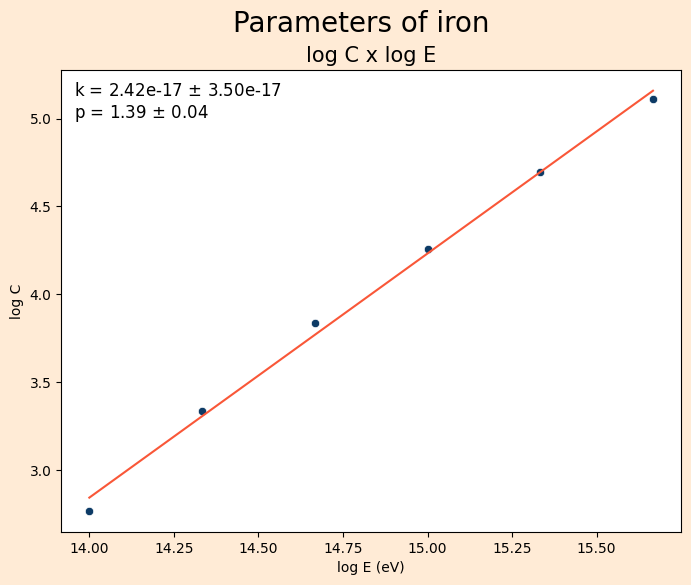

In [4]:
# Fit do ferro

C = [585.4,2158,6822,1.819E4,4.942E04,1.286E05]
s = [2.218,1.993,1.841, 1.66,1.607,1.522]
E = [1E14, 2.15E14, 4.64E14,1E15,2.15E15,4.64E15]

logC = np.log10(C)
logE = np.log10(E)


fig, ax = plt.subplots(figsize = (8, 6), facecolor = '#FFEBD6')
fig.suptitle('Parameters of iron', size = 20)
#fig.tight_layout()


ax.set_title('log C x log E', size = 15)
ax.set_xlabel('log E (eV)')
ax.set_ylabel('log C')
ax.set_facecolor('white')


#Fit
def power(x, k, p):
    return np.log10(k*x**p)

initial_guess = [1,1]

coefficients, cov = curve_fit(power, E, np.log10(C), p0=initial_guess)

inc = np.sqrt(np.diag(cov))
print(np.sqrt(np.diag(cov)))

print(power(E,*coefficients))

ax.plot(logE, power(E,*coefficients), color = '#F95738')
sns.scatterplot(x = logE, y = logC, color = '#0D3B66', ax = ax)

ax.legend(title = 'k = {:.2e} $\pm$ {:.2e}\np = {:.2f} $\pm$ {:.2f}'
          .format(coefficients[0],inc[0],coefficients[1],inc[1]),
          title_fontsize = 12,facecolor = 'white', frameon = False)


logE_0_array = ((np.log10(C/coefficients[0]))/coefficients[1])

logE_0 = logE_0_array.tolist()

data = {
    'logC':logC,
    'logE_S':logE,
    'logE_R':logE_0
}

df = pl.DataFrame(data)

df = df.with_columns(
        abs((((pl.col('logE_R')-pl.col('logE_S'))/pl.col('logE_S'))*100)).alias('error (%)')
)
df